In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Kokoro = pd.read_csv('Heart_disease_statlog.csv')

1.Age: Patients Age in years (Numeric)

2.Sex: Gender (Male : 1; Female : 0) (Nominal)

3.cp: Type of chest pain experienced by patient. This term categorized into 4 category.
0 typical angina, 1 atypical angina, 2 non- anginal pain, 3 asymptomatic (Nominal)

4.trestbps: patient's level of blood pressure at resting mode in mm/HG (Numerical)

5.chol: Serum cholesterol in mg/dl (Numeric)

6.fbs: Blood sugar levels on fasting > 120 mg/dl represents as 1 in case of true and 0 as false (Nominal)

7.restecg: Result of electrocardiogram while at rest are represented in 3 distinct values
0 : Normal 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
2: showing probable or definite left ventricular hypertrophyby Estes' criteria (Nominal)

8.thalach: Maximum heart rate achieved (Numeric)

9.exang: Angina induced by exercise 0 depicting NO 1 depicting Yes (Nominal)

10.oldpeak: Exercise induced ST-depression in relative with the state of rest (Numeric)

11.slope: ST segment measured in terms of slope during peak exercise
0: up sloping; 1: flat; 2: down sloping(Nominal)

12.ca: The number of major vessels (0–3)(nominal)

13.thal: A blood disorder called thalassemia
0: NULL 1: normal blood flow 2: fixed defect (no blood flow in some part of the heart) 3: reversible defect (a blood flow is observed but it is not normal(nominal)

14.target: It is the target variable which we have to predict 1 means patient is suffering from heart disease and 0 means patient is normal.

In [11]:
Kokoro.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,70,1,3,130,322,0,2,109,0,2.4,1,3,1,1
1,67,0,2,115,564,0,2,160,0,1.6,1,0,3,0
2,57,1,1,124,261,0,0,141,0,0.3,0,0,3,1
3,64,1,3,128,263,0,0,105,1,0.2,1,1,3,0
4,74,0,1,120,269,0,2,121,1,0.2,0,1,1,0


In [35]:
Kokoro.shape

(270, 14)

In [ ]:
Kokoro.info()

In [ ]:
Kokoro.describe().T

In [ ]:
Kokoro.isna().sum()

In [ ]:
Kokoro.duplicated().sum()

1. Distribuição de Idades

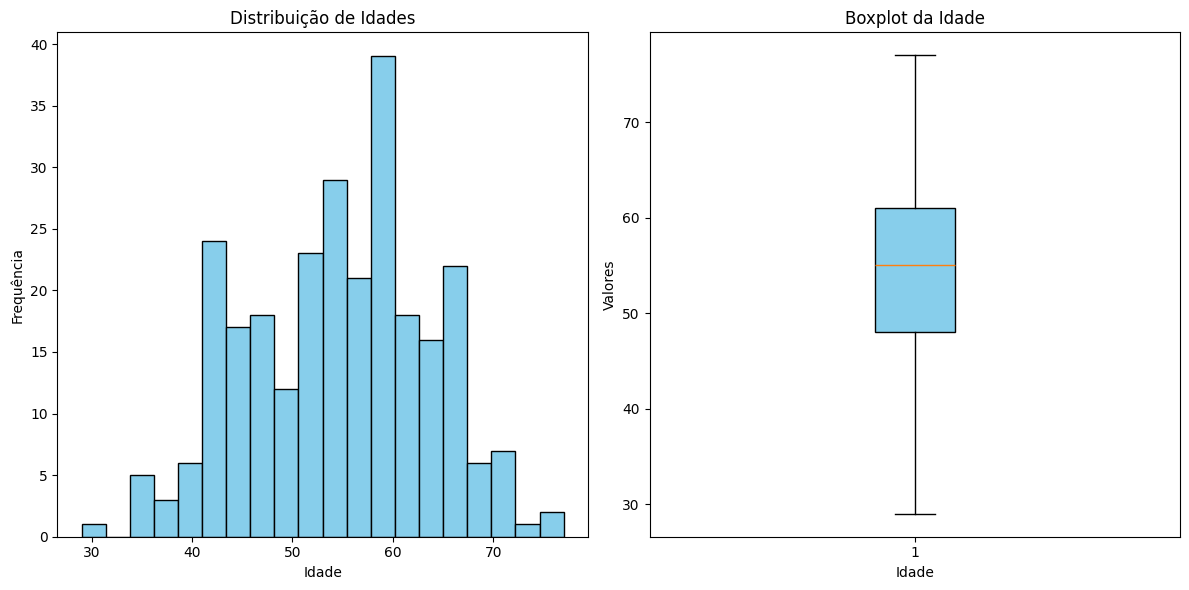

In [ ]:
# Ajustar o tamanho da figura
fig = plt.figure(figsize=(12, 6))

# Criar subplots
ax_array = fig.subplots(1, 2, squeeze=False)

# Histograma da idade
ax_array[0, 0].hist(Kokoro['age'], bins=20, color='skyblue', edgecolor='black')
ax_array[0, 0].set_title('Distribuição de Idades')
ax_array[0, 0].set_xlabel('Idade')
ax_array[0, 0].set_ylabel('Frequência')

# Boxplot da idade
ax_array[0, 1].boxplot(Kokoro['age'], patch_artist=True, boxprops=dict(facecolor='skyblue'))
ax_array[0, 1].set_title('Boxplot da Idade')
ax_array[0, 1].set_xlabel('Idade')
ax_array[0, 1].set_ylabel('Valores')

plt.tight_layout()
plt.show()

2. Distribuição por Sexo

In [22]:
# Trasformar a coluna de sexo em categórica
Kokoro['sex'] = Kokoro['sex'].map(
{
0: 'Feminino', 
1: 'Masculino'
})

In [23]:
# Contagem de valores
Kokoro['sex'].value_counts()

sex
Masculino    183
Feminino      87
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x264a88a2360>,
 [Text(-0.9328529251768981, -0.5829111596023057, 'Masculino'),
  Text(0.9328529251768982, 0.5829111596023056, 'Feminino')],
 [Text(-0.508828868278308, -0.3179515416012576, '67.8%'),
  Text(0.5088288682783081, 0.31795154160125755, '32.2%')])

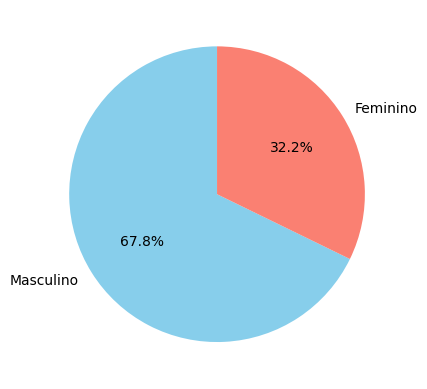

In [24]:
# Gráfico de pizza
plt.pie(Kokoro['sex'].value_counts(), 
labels=['Masculino', 'Feminino'], 
autopct='%1.1f%%', 
startangle=90, 
colors=['skyblue', 'salmon']
)


3. Tipos de Dor no Peito (cp)

In [36]:
# Trasformar a coluna de cp em categórica
Kokoro['cp'] = Kokoro['cp'].map(
{
0: 'Angina típica',
1: 'Angina atípica', 
2: 'Dor não cardíaca', 
3: 'Assintomático'
})

In [40]:
# Transformando a coluna target em categórica
Kokoro['target'] = Kokoro['target'].map(
{
0: 'Sem doença cardíaca', 
1: 'Com doença cardíaca'
})

Text(42.807758487654326, 0.5, 'Frequência')

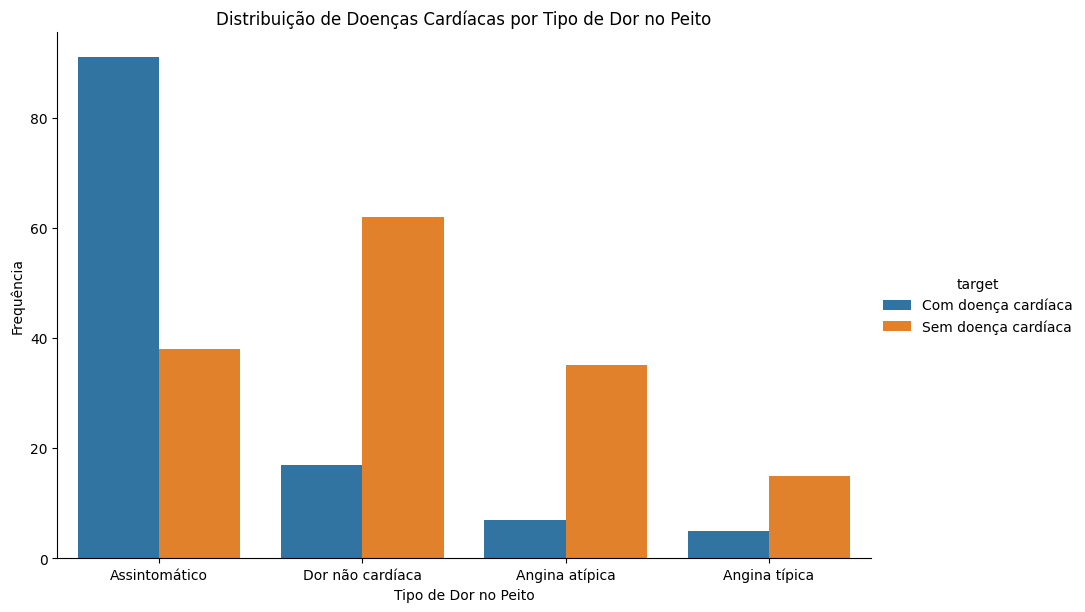

In [ ]:
sns.catplot(
data=Kokoro,
x='cp', # tipo de dor no peito
hue='target', # separar por doença ou não, sendo 1 para doença e 0 para não
kind = 'count', # tipo de gráfico
height= 6, # altura
aspect=1.5, # largura
)

plt.title('Distribuição de Doenças Cardíacas por Tipo de Dor no Peito')
plt.xlabel('Tipo de Dor no Peito')
plt.ylabel('Frequência')

4. Pressão Arterial em Repouso(trestbps)

Text(0.5, 1.0, 'Boxplot da Pressão Arterial em Repouso')

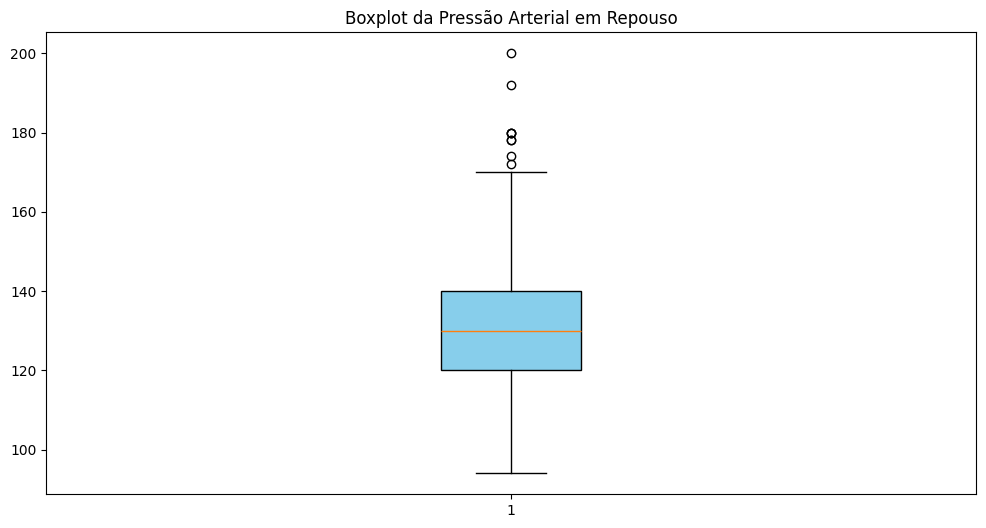

In [65]:
plt.figure(figsize=(12, 6))
plt.boxplot(Kokoro['trestbps'], 
patch_artist=True, 
boxprops=dict(facecolor='skyblue'))

plt.title('Boxplot da Pressão Arterial em Repouso')

Text(0, 0.5, 'Frequência')

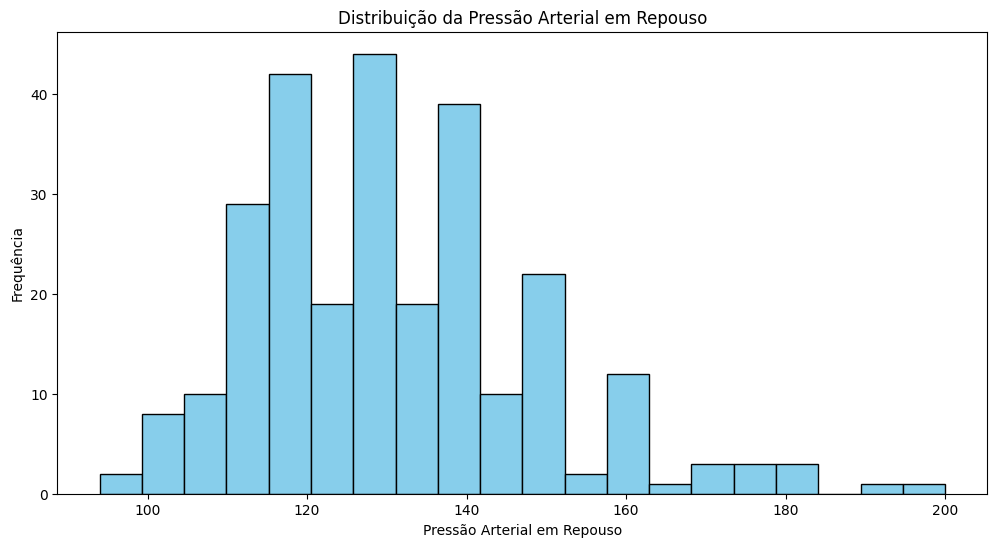

In [107]:
plt.figure(figsize=(12, 6))
plt.hist(Kokoro['trestbps'], 
bins=20, 
color='skyblue', 
edgecolor='black')

plt.title('Distribuição da Pressão Arterial em Repouso')
plt.xlabel('Pressão Arterial em Repouso')
plt.ylabel('Frequência')


In [45]:
Kokoro['trestbps'].describe()

count    270.000000
mean     131.344444
std       17.861608
min       94.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: trestbps, dtype: float64

In [61]:
Kokoro['trestbps'].infer_objects()

0      130
1      115
2      124
3      128
4      120
      ... 
265    172
266    120
267    140
268    140
269    160
Name: trestbps, Length: 270, dtype: int64

In [70]:
# Calcular o IQR (Interquartile Range)
Q1 = Kokoro['trestbps'].quantile(0.25)
Q3 = Kokoro['trestbps'].quantile(0.75)
IQR = Q3 - Q1

# Definir os limites para os outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtrar os dados para remover os outliers
Pressão_Arterial_em_Repouso = Kokoro[(Kokoro['trestbps'] >= limite_inferior) & (Kokoro['trestbps'] <= limite_superior)]

print(f'Dados sem outliers: {Pressão_Arterial_em_Repouso.shape}')

Dados sem outliers: (261, 14)


array([[<Axes: title={'center': 'trestbps'}>]], dtype=object)

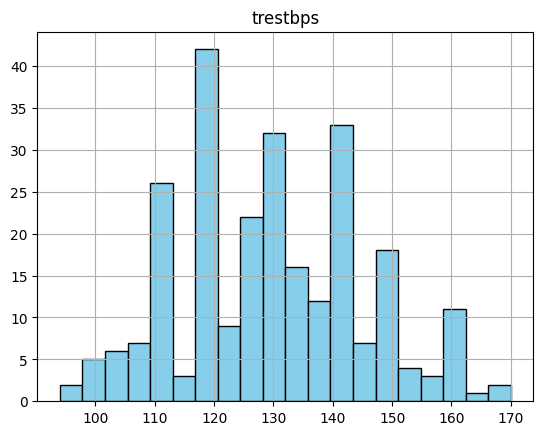

In [ ]:
Pressão_Arterial_em_Repouso.hist('trestbps', 
bins=20, 
color='skyblue', 
edgecolor='black'
)

5. Colesterol (chol)

array([[<Axes: title={'center': 'chol'}>]], dtype=object)

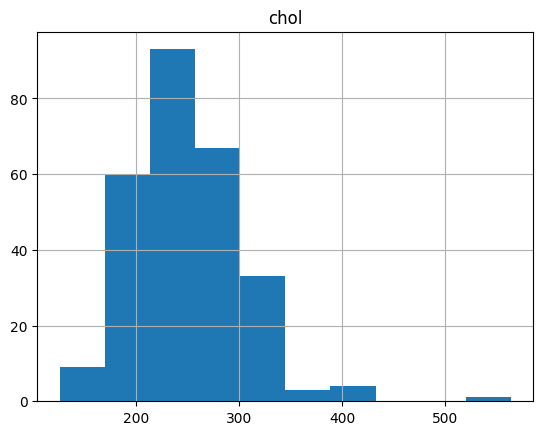

In [67]:
Kokoro.hist('chol')

<Axes: >

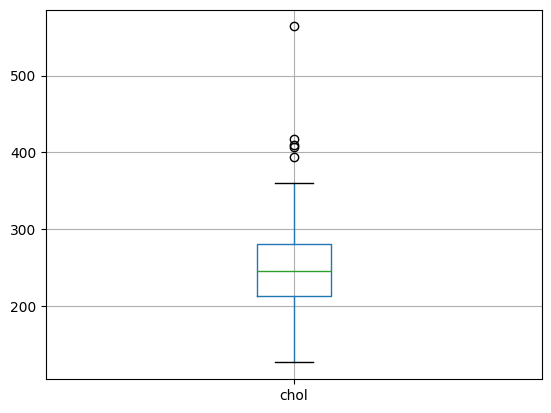

In [68]:
Kokoro.boxplot('chol')

In [69]:
# Calcular o IQR (Interquartile Range)
Q1 = Kokoro['chol'].quantile(0.25)
Q3 = Kokoro['chol'].quantile(0.75)
IQR = Q3 - Q1

# Definir os limites para os outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtrar os dados para remover os outliers
Colesterol_sem_outliers = Kokoro[(Kokoro['chol'] >= limite_inferior) & (Kokoro['chol'] <= limite_superior)]

print(f'Dados sem outliers: {Colesterol_sem_outliers}')

Dados sem outliers:      age        sex                cp  trestbps  chol  fbs  restecg  thalach  \
0     70  Masculino     Assintomático       130   322    0        2      109   
2     57  Masculino    Angina atípica       124   261    0        0      141   
3     64  Masculino     Assintomático       128   263    0        0      105   
4     74   Feminino    Angina atípica       120   269    0        2      121   
5     65  Masculino     Assintomático       120   177    0        0      140   
..   ...        ...               ...       ...   ...  ...      ...      ...   
265   52  Masculino  Dor não cardíaca       172   199    1        0      162   
266   44  Masculino    Angina atípica       120   263    0        0      173   
267   56   Feminino    Angina atípica       140   294    0        2      153   
268   57  Masculino     Assintomático       140   192    0        0      148   
269   67  Masculino     Assintomático       160   286    0        2      108   

     exang  oldpeak

array([[<Axes: title={'center': 'chol'}>]], dtype=object)

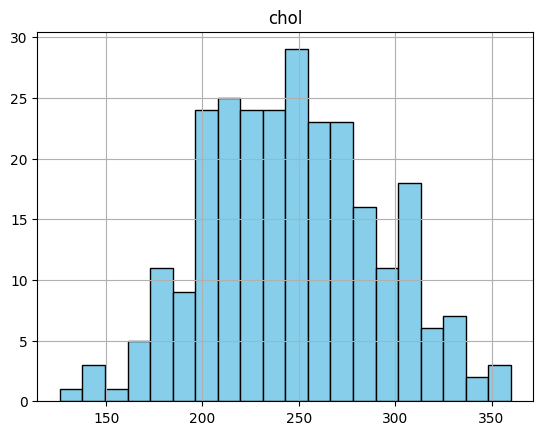

In [ ]:
Colesterol_sem_outliers.hist(
'chol', 
bins=20, 
color='skyblue', 
edgecolor='black')

6. Relação entre Máximo de Batimentos Cardíacos (thalach) e Idade(age)

In [86]:
print('Idade máxima:',Kokoro['age'].max())
print('Idade mínima:',Kokoro['age'].min())

Idade máxima: 77
Idade mínima: 29


Text(0, 0.5, 'Idade')

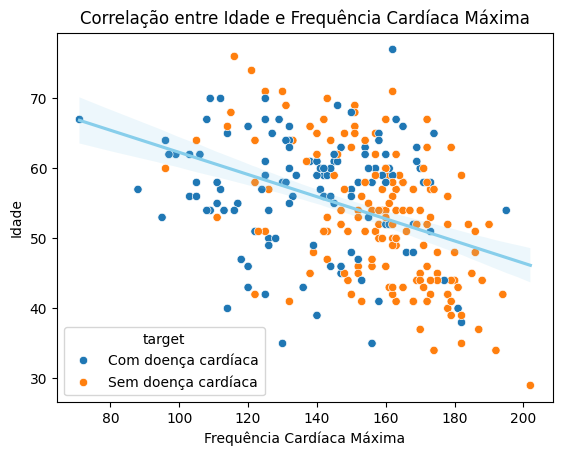

In [83]:
sns.scatterplot(
data=Kokoro, 
x='thalach', 
y='age', 
hue='target'
)

sns.regplot(
data=Kokoro,
x='thalach', 
y='age',
scatter=False, 
color='skyblue'
)

plt.title('Correlação entre Idade e Frequência Cardíaca Máxima')
plt.xlabel('Frequência Cardíaca Máxima')
plt.ylabel('Idade')

7. Distribuição da Variável Alvo (target)

In [87]:
Kokoro['target'].unique()

array(['Com doença cardíaca', 'Sem doença cardíaca'], dtype=object)

C:\Users\Aszur\AppData\Local\Temp\ipykernel_5800\914005786.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


Text(0, 0.5, 'Frequência')

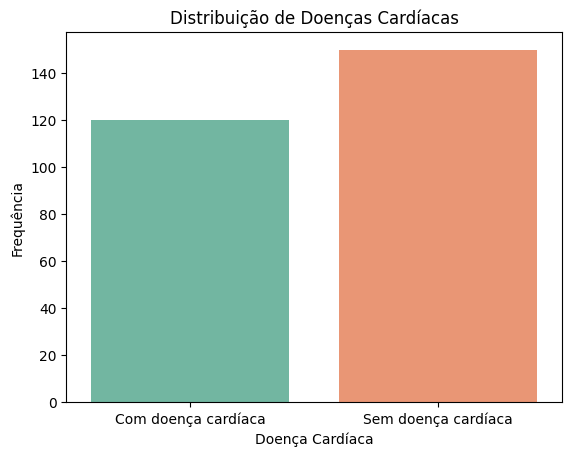

In [92]:
sns.countplot(
data=Kokoro,
x='target',
palette='Set2'
)

plt.title('Distribuição de Doenças Cardíacas')
plt.xlabel('Doença Cardíaca')
plt.ylabel('Frequência')

8. Correlação entre Variáveis

<Axes: >

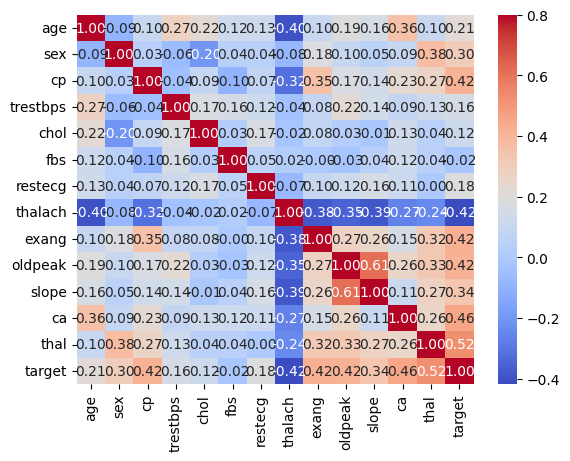

In [103]:
# Convert categorical columns to numerical values
Kokoro_numérico = Kokoro.copy()
Kokoro_numérico['sex'] = Kokoro_numérico['sex'].map({'Masculino': 1, 'Feminino': 0})
Kokoro_numérico['cp'] = Kokoro_numérico['cp'].map({'Angina típica': 0, 'Angina atípica': 1, 'Dor não cardíaca': 2, 'Assintomático': 3})
Kokoro_numérico['target'] = Kokoro_numérico['target'].map({'Com doença cardíaca': 1, 'Sem doença cardíaca': 0})

# Calculate the correlation matrix
Matrix_Correlação = Kokoro_numérico.corr()

# Plot the heatmap
sns.heatmap(Matrix_Correlação, annot=True, cmap='coolwarm', vmax=0.8, fmt='.2f')

9. Tentativa de Modelo de Treinamento

In [104]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [106]:
# Pré-processamento dos dados
X = Kokoro_numérico.drop('target', axis=1) # Variáveis independentes
y = Kokoro_numérico['target'] # Variável dependente

# Dividir os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizar os dados
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Treinar o modelo
modelo = LogisticRegression()
modelo.fit(X_train, y_train)

# Fazer previsões
y_pred = modelo.predict(X_test)

# Avaliar o modelo
acurácia = accuracy_score(y_test, y_pred)
Matrix_de_Confusão = confusion_matrix(y_test, y_pred)
Relatório_de_Classificação = classification_report(y_test, y_pred)

print(f'Acurácia: {acurácia}')
print(f'Matriz de Confusão:\n{Matrix_de_Confusão}')
print(f'Relatório de Classificação:\n{Relatório_de_Classificação}')


Acurácia: 0.9259259259259259
Matriz de Confusão:
[[32  1]
 [ 3 18]]
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94        33
           1       0.95      0.86      0.90        21

    accuracy                           0.93        54
   macro avg       0.93      0.91      0.92        54
weighted avg       0.93      0.93      0.93        54

